In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscipopt import Model, quicksum

DEPOT = 0

AKZENT_FARBE = "#115074"
PAAR_FARBE = "#3573a6"
EINZEL_FARBE = "#c66a2b"

# Kundenbesuche: Welche Besuche gehören auf dieselbe Tour?

Ein Vertriebler muss 11 Kunden besuchen. Jeder Besuchstag beginnt und endet in
der Zentrale. Auf eine Tour passen höchstens zwei Kunden, und keine Tour
darf die Tagesgrenze an Fahrzeit überschreiten.

Weil die Orte zufällig in einem Quadrat liegen und wir die Fahrzeit aus dem
Abstand berechnen, ist die Fahrt in beide Richtungen gleich. Die Reihenfolge
spielt deshalb keine Rolle: Es geht nur darum, welche Kunden sich eine Tour
teilen.

## Orte

Elf Kundenorte zufällig im Quadrat von −50 bis +50, die Zentrale in der Mitte.
Bei so wenigen Orten passt die ganze Fahrzeitentabelle auf den Schirm.

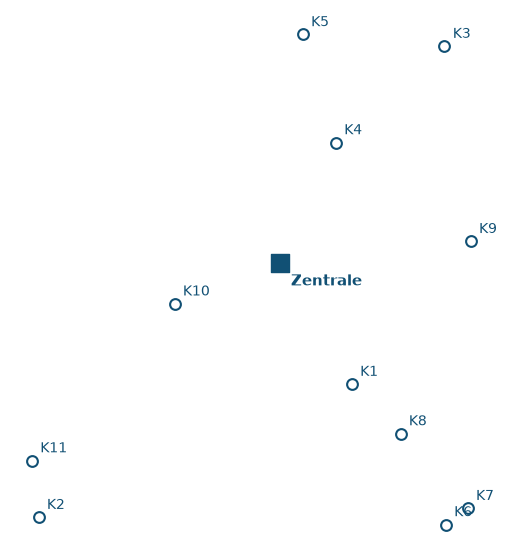

In [27]:
ANZAHL_KUNDEN = 11
HALBE_KARTE = 50.0

# Der Seed 0 im Zufallsgenerator sorgt dafür, dass bei jedem Durchlauf
# dieselben Orte entstehen.
rng = np.random.default_rng(0)
kunden = tuple(range(1, ANZAHL_KUNDEN + 1))

koordinaten = {DEPOT: (0.0, 0.0)}
for kunde, (x, y) in zip(
    kunden,
    rng.uniform(low=-HALBE_KARTE, high=HALBE_KARTE, size=(ANZAHL_KUNDEN, 2)),
):
    koordinaten[kunde] = (float(x), float(y))

orte = (DEPOT, *kunden)
namen = {DEPOT: "Zentrale", **{kunde: f"K{kunde}" for kunde in kunden}}


def karte_zeichnen(touren=()):
    """Zeichnet die Orte und optional die gewählten Touren."""
    _, achse = plt.subplots(figsize=(7, 7))

    for stops in touren:
        pfad = (DEPOT, *stops, DEPOT)
        achse.plot(
            [koordinaten[ort][0] for ort in pfad],
            [koordinaten[ort][1] for ort in pfad],
            color=EINZEL_FARBE if len(stops) == 1 else PAAR_FARBE,
            linewidth=1.8,
            alpha=0.85,
            zorder=1,
        )

    achse.scatter(
        [koordinaten[kunde][0] for kunde in kunden],
        [koordinaten[kunde][1] for kunde in kunden],
        s=60,
        facecolor="white",
        edgecolor=AKZENT_FARBE,
        linewidth=1.5,
        zorder=2,
    )
    for kunde in kunden:
        achse.annotate(
            namen[kunde],
            koordinaten[kunde],
            xytext=(6, 6),
            textcoords="offset points",
            color=AKZENT_FARBE,
            fontsize=10,
        )
    achse.scatter(0.0, 0.0, marker="s", s=150, color=AKZENT_FARBE, zorder=3)
    achse.annotate(
        "Zentrale",
        (0.0, 0.0),
        xytext=(8, -16),
        textcoords="offset points",
        color=AKZENT_FARBE,
        fontsize=11,
        fontweight="bold",
    )
    achse.set_aspect("equal")
    achse.set_xticks([])
    achse.set_yticks([])
    for rand in achse.spines.values():
        rand.set_visible(False)
    plt.show()


karte_zeichnen()

## Fahrzeiten

Die Fahrzeit ist der Abstand zwischen zwei Orten mal einem Faktor, auf ganze
Minuten gerundet. Der Faktor 0,8 hält alle Fahrzeiten in einem Bereich, in dem
die Tagesgrenze von 120 Minuten sinnvoll greift. Die Tabelle zeigt jede
Verbindung von jedem Ort zu jedem anderen; die Fahrt in beide Richtungen ist
gleich.

In [29]:
orte_vektoren = {ort: np.array(koordinaten[ort]) for ort in orte}

# Der Faktor 0,8 rechnet den Abstand in Fahrminuten um.
fahrzeit = {
    (ort_a, ort_b): round(
        float(np.linalg.norm(orte_vektoren[ort_a] - orte_vektoren[ort_b])) * 0.8
    )
    for ort_a in orte
    for ort_b in orte
}

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print("FAHRZEITEN IN MINUTEN")
print(
    pd.DataFrame(
        [[fahrzeit[a, b] for b in orte] for a in orte],
        index=[namen[ort] for ort in orte],
        columns=[namen[ort] for ort in orte],
    )
)

FAHRZEITEN IN MINUTEN
          Zentrale  K1  K2  K3  K4  K5  K6  K7  K8  K9  K10  K11
Zentrale         0  21  53  41  20  35  47  47  32  29   17   48
K1              21   0  52  53  37  54  26  26  11  28   30   50
K2              53  52   0  95  73  84  62  65  57  78   39    9
K3              41  53  95   0  22  22  73  70  59  30   57   89
K4              20  37  73  22   0  17  61  59  45  25   35   67
K5              35  54  84  22  17   0  78  76  63  41   45   77
K6              47  26  62  73  61  78   0   4  15  43   53   64
K7              47  26  65  70  59  76   4   0  15  41   54   67
K8              32  11  57  59  45  63  15  15   0  31   40   56
K9              29  28  78  30  25  41  43  41  31   0   46   75
K10             17  30  39  57  35  45  53  54  40  46    0   32
K11             48  50   9  89  67  77  64  67  56  75   32    0


## Mögliche Touren und Tagesgrenze

Eine Tour ist ein Kunde allein oder zwei Kunden zusammen. Die Fahrzeit ist
Zentrale → Kunde(n) → Zentrale. Die Tagesgrenze setzen wir fest auf 120 Minuten:
Kein Besuchstag darf länger dauern. Touren darüber nehmen wir gar nicht erst
als Option auf.

In [30]:
TAGESGRENZE = 120

paare: dict[tuple[int, int], int] = {}
for erster in kunden:
    for zweiter in kunden:
        if zweiter <= erster:
            continue
        dauer = (
            fahrzeit[DEPOT, erster]
            + fahrzeit[erster, zweiter]
            + fahrzeit[zweiter, DEPOT]
        )
        if dauer <= TAGESGRENZE:
            paare[(erster, zweiter)] = dauer

einzel: dict[int, int] = {}
for kunde in kunden:
    dauer = 2 * fahrzeit[DEPOT, kunde]
    if dauer <= TAGESGRENZE:
        einzel[kunde] = dauer

print(f"Tagesgrenze: {TAGESGRENZE} Minuten")
print(f"Mögliche Touren: {len(paare)} zu zweit, {len(einzel)} allein")

Tagesgrenze: 120 Minuten
Mögliche Touren: 32 zu zweit, 11 allein


## Entscheidungen

Eine binäre Variable pro möglicher Tour. Der Wert 1 bedeutet „diese Tour
nutzen wir“.

In [31]:
modell = Model(problemName="kundenbesuche")
modell.hideOutput()
modell.setParam(name="limits/time", value=30.0)

x = {paar: modell.addVar(name=f"tour_{paar[0]}_{paar[1]}", vtype="B") for paar in paare}
z = {kunde: modell.addVar(name=f"allein_{kunde}", vtype="B") for kunde in einzel}

## Regel: Jeder Kunde genau einmal

Jeder Kunde taucht in genau einer gewählten Tour auf, entweder zu zweit oder
allein.

In [32]:
for kunde in kunden:
    modell.addCons(
        cons=quicksum(x[paar] for paar in paare if kunde in paar) + z[kunde] == 1,
        name=f"kunde_{kunde}_genau_einmal",
    )

## Zielfunktion: möglichst wenig Fahrzeit

Die Gesamtfahrzeit aller gewählten Touren soll minimal werden.

In [33]:
modell.setObjective(
    expr=quicksum(paare[paar] * x[paar] for paar in paare)
    + quicksum(einzel[kunde] * z[kunde] for kunde in einzel),
    sense="minimize",
)

## Optimieren

In [34]:
modell.optimize()
status = str(modell.getStatus())
if modell.getNSols() == 0:
    raise RuntimeError(f"Keine zulässige Lösung gefunden (Status: {status}).")

loesung = modell.getBestSol()
gewaehlte_paare = [
    paar
    for paar, variable in x.items()
    if modell.getSolVal(sol=loesung, expr=variable) > 0.5
]
gewaehlte_einzel = [
    kunde
    for kunde, variable in z.items()
    if modell.getSolVal(sol=loesung, expr=variable) > 0.5
]

touren = sorted(
    [(paar, paare[paar]) for paar in gewaehlte_paare]
    + [((kunde,), einzel[kunde]) for kunde in gewaehlte_einzel],
    key=lambda eintrag: eintrag[1],
    reverse=True,
)

print(f"Solverstatus: {status}")
print(
    f"Touren: {len(touren)} "
    f"({len(gewaehlte_paare)} zu zweit, {len(gewaehlte_einzel)} allein)"
)
print(f"Gesamte Fahrzeit: {int(modell.getSolObjVal(sol=loesung))} Minuten")
print()
print(
    pd.DataFrame(
        {
            "Besuche": [
                " → ".join(namen[kunde] for kunde in stops) for stops, _ in touren
            ],
            "Fahrzeit": [dauer for _, dauer in touren],
        },
        index=[f"Tour {position}" for position in range(1, len(touren) + 1)],
    ).to_string()
)

Solverstatus: optimal
Touren: 6 (5 zu zweit, 1 allein)
Gesamte Fahrzeit: 478 Minuten

         Besuche  Fahrzeit
Tour 1  K2 → K11       110
Tour 2   K3 → K5        98
Tour 3   K6 → K7        98
Tour 4   K4 → K9        74
Tour 5   K1 → K8        64
Tour 6       K10        34


## Tourenplan

Die gewählten Touren auf der Karte. Orange sind Einzeltouren.

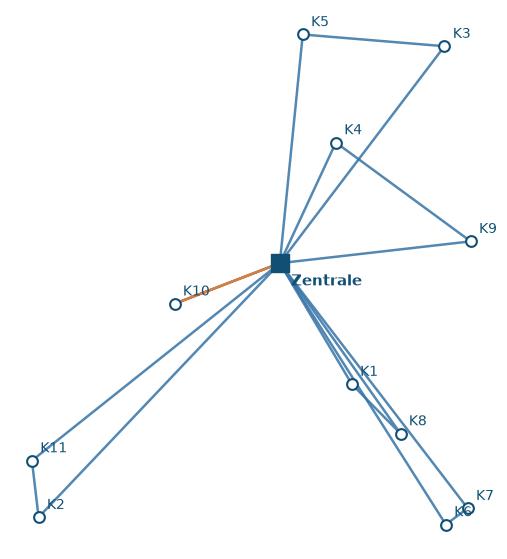

In [35]:
karte_zeichnen(touren=tuple(stops for stops, _ in touren))

## Alternative: die Bogen-Formulierung

In der Literatur modelliert man Touren oft über einzelne Fahrten zwischen
allen Orten, das Depot eingeschlossen. Jeder Ort hat dann genau eine
ankommende und eine abgehende Fahrt, und eine Zusatzregel verhindert, dass ein
Kunde als Zwischenstopp in einer längeren Kette auftaucht. Diese
Bogen-Formulierung ist allgemeiner und die Grundlage von Fahrzeugrouten-
Modellen. Für dieses Beispiel wählen wir bewusst die einfachere
Tour-Variante: Jede Variable ist eine ganze Tour, dadurch bleibt die
Tagesgrenze direkt sichtbar.